# Medical RAG + LLM Evaluation Pipeline
### Grounded Question Answering over PubMedQA with FAISS Retrieval & Statistical Hallucination Analysis

**Author:** Kushagra Aggarwal — MS Data Science, Northeastern University

---

## Project Overview

This project builds and **evaluates** a Retrieval-Augmented Generation (RAG) system for biomedical
question answering. The goal is not just to generate answers, but to **measure how grounded those
answers are** in retrieved evidence — directly quantifying hallucination.

**Pipeline:**
1. **Ingest** the PubMedQA corpus and chunk biomedical abstracts.
2. **Embed** chunks with a sentence-transformer model and index them in a **FAISS** vector store.
3. **Retrieve** the most relevant evidence for each question (semantic search).
4. **Generate** a grounded answer with an instruction-tuned LLM, conditioned only on retrieved context.
5. **Evaluate** with a baseline (no-RAG) vs RAG comparison across:
   - **Classification metrics** (accuracy, macro-F1) on the yes/no/maybe decision,
   - **Retrieval quality** (hit-rate / recall@k),
   - **Faithfulness / grounding** (a hallucination proxy: does the answer rely on retrieved evidence?).
6. **Visualize** results and ship an interactive **Gradio demo dashboard**.

> **Why this design?** RAG reduces hallucination by forcing the model to answer from retrieved
> evidence rather than parametric memory. This notebook *measures* that effect rather than assuming it.


## 0. Environment Setup

Target: **Google Colab GPU runtime** (`Runtime → Change runtime type → T4 GPU`).
All package versions are pinned-by-family to keep the notebook reproducible.

In [1]:
# Verify a GPU is attached (RAG generation runs much faster on GPU)
!nvidia-smi

Wed Jun  3 15:48:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Core RAG + evaluation stack
!pip install -q -U \
    transformers accelerate bitsandbytes sentencepiece \
    sentence-transformers faiss-cpu \
    datasets evaluate scikit-learn \
    pandas matplotlib seaborn \
    gradio
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 

In [3]:
# Hugging Face authentication

import os
from huggingface_hub import login

token = None
try:
    from google.colab import userdata          # Colab Secrets
    token = userdata.get("HF_TOKEN")
except Exception:
    token = os.environ.get("HF_TOKEN")          # local / other env

if token:
    login(token)
    print("Authenticated with Hugging Face Hub.")
else:
    print("No HF_TOKEN found. The models used here are public, so this is optional.\n"
          "Add a token only if you hit a gated-repo error.")

Authenticated with Hugging Face Hub.


In [4]:
# Reproducibility
import random, numpy as np, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 1. Data Ingestion & Preprocessing

We use **PubMedQA** (`pqa_labeled`): 1,000 expert-annotated biomedical questions, each paired with a
PubMed abstract (the *context*) and a yes/no/maybe `final_decision`.

For RAG we treat every abstract as a **document** to be retrieved. The yes/no/maybe label lets us
evaluate answer correctness *quantitatively*, while the free-text question lets us test retrieval.

In [5]:
from datasets import load_dataset

# PubMedQA, labeled subset (1k expert-annotated yes/no/maybe QA pairs).
# NOTE: the old bare id "pubmed_qa" no longer resolves on recent `datasets`
# versions, which now require the canonical "namespace/name" form.
try:
    ds = load_dataset("qiaojin/PubMedQA", "pqa_labeled")
except Exception as e:
    print("Primary repo failed, falling back to bigbio mirror:", e)
    ds = load_dataset("bigbio/pubmed_qa", "pubmed_qa_labeled_fold0_source")

raw = ds["train"]
print(raw)
print("\nExample question:", raw[0]["question"])
print("Decision:", raw[0]["final_decision"])

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
    num_rows: 1000
})

Example question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Decision: yes


In [6]:
import pandas as pd

def flatten(example, idx):
    # PubMedQA context is a dict with a list of abstract sentences under "contexts"
    ctx = example["context"]
    if isinstance(ctx, dict):
        sentences = ctx.get("contexts") or ctx.get("abstract") or []
        if isinstance(sentences, str):
            sentences = [sentences]
        passage = " ".join(sentences)
    else:
        passage = str(ctx)
    return {
        "doc_id": idx,
        "question": example["question"],
        "passage": passage,
        "label": example["final_decision"].strip().lower(),
    }

records = [flatten(raw[i], i) for i in range(len(raw))]
df = pd.DataFrame(records)
df = df[df["passage"].str.len() > 0].reset_index(drop=True)

print("Usable QA pairs:", len(df))
print("\nLabel distribution:")
print(df["label"].value_counts())
df.head(3)

Usable QA pairs: 1000

Label distribution:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64


,doc_id,question,passage,label
0,0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes
1,1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no
2,2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes


In [7]:
# Split QUESTIONS into a held-out eval set, but index the FULL corpus.
#
# IMPORTANT: a question can only be answered by RAG if its source passage is
# actually in the index. Previously we indexed only train_df and queried eval_df,
# so the correct document was never retrievable -> hit-rate was 0 by construction.
# Here every passage is indexed; we simply hold out a subset of questions to query.
from sklearn.model_selection import train_test_split

corpus_df = df.reset_index(drop=True)          # ALL passages get indexed
_, eval_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
eval_df = eval_df.reset_index(drop=True)
print(f"Indexed corpus passages: {len(corpus_df)}  |  Eval questions: {len(eval_df)}")

Indexed corpus passages: 1000  |  Eval questions: 200


## 2. Build the FAISS Vector Store

**Chunking:** abstracts are short, but we still split long passages into overlapping windows so a
single dense embedding isn't asked to represent too much text — this improves retrieval precision.

**Embeddings:** `sentence-transformers/all-MiniLM-L6-v2` — a fast, strong general-purpose encoder
(384-dim). We L2-normalize embeddings and use an **inner-product FAISS index**, which is equivalent
to cosine similarity on normalized vectors.

In [8]:
def chunk_text(text, chunk_size=80, overlap=20):
    """Word-window chunking with overlap. Returns a list of chunk strings."""
    words = text.split()
    if len(words) <= chunk_size:
        return [text]
    chunks, start = [], 0
    while start < len(words):
        chunks.append(" ".join(words[start:start + chunk_size]))
        start += chunk_size - overlap
    return chunks

# Build the chunk-level corpus over ALL passages, remembering each chunk's source doc + label
corpus_chunks, chunk_meta = [], []
for _, row in corpus_df.iterrows():
    for ci, ch in enumerate(chunk_text(row["passage"])):
        corpus_chunks.append(ch)
        chunk_meta.append({"doc_id": row["doc_id"], "label": row["label"], "chunk_id": ci})

print(f"{len(corpus_df)} passages -> {len(corpus_chunks)} chunks "
      f"(avg {len(corpus_chunks)/len(corpus_df):.1f} chunks/passage)")

1000 passages -> 3831 chunks (avg 3.8 chunks/passage)


In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)

chunk_embeddings = embedder.encode(
    corpus_chunks,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # enables cosine similarity via inner product
)
print("Embedding matrix shape:", chunk_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Embedding matrix shape: (3831, 384)


In [10]:
import faiss

dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings.astype("float32"))
print("FAISS index built. Vectors indexed:", index.ntotal)

FAISS index built. Vectors indexed: 3831


In [11]:
def retrieve(query, k=4):
    """Return top-k (chunk_text, metadata, score) for a query."""
    q_emb = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(q_emb.astype("float32"), k)
    results = []
    for score, i in zip(scores[0], idxs[0]):
        results.append({
            "text": corpus_chunks[i],
            "meta": chunk_meta[i],
            "score": float(score),
        })
    return results

# Sanity check
demo = retrieve(eval_df.iloc[0]["question"], k=3)
print("Query:", eval_df.iloc[0]["question"], "\n")
for r in demo:
    print(f"[{r['score']:.3f}] doc {r['meta']['doc_id']}: {r['text'][:120]}...")

Query: The promise of specialty pharmaceuticals: are they worth the price? 

[0.685] doc 411: Specialty pharmaceuticals have evolved beyond their status as niche drugs designed to treat rare conditions and are now ...
[0.646] doc 411: lack of robust pharmacoeconomic data. To outline emerging strategies and case study examples for the medical and pharmac...
[0.626] doc 411: to assess value, the cost impacts of these specialty drugs can be appropriately controlled....


## 3. The Generator (Instruction-Tuned LLM)

We use **`google/flan-t5-base`** as the answer generator. It is small enough to run comfortably on a
Colab T4, instruction-tuned (so it follows the yes/no/maybe constraint well), and deterministic with
greedy decoding — which keeps the evaluation reproducible.

> The same RAG pattern works with a larger model (e.g. a 7B chat model in 4-bit). We choose a small,
> fast model here so the **evaluation** — the point of the project — runs end-to-end in minutes.

In [12]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

GEN_MODEL = "google/flan-t5-base"
gen_tok = AutoTokenizer.from_pretrained(GEN_MODEL)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL).to(DEVICE)
gen_model.eval()
print(f"Loaded generator: {GEN_MODEL}")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded generator: google/flan-t5-base


In [13]:
import torch

YESNOMAYBE_INSTR = (
    "You are a biomedical question-answering assistant. "
    "Using ONLY the context, answer the question with exactly one word: yes, no, or maybe."
)

def generate(question, context, max_new_tokens=8):
    """Greedy, deterministic generation. Truncates context to fit the 512-token window."""
    prompt = f"{YESNOMAYBE_INSTR}\n\nContext: {context}\n\nQuestion: {question}\n\nAnswer:"
    inputs = gen_tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = gen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return gen_tok.decode(out[0], skip_special_tokens=True).strip()

In [14]:
def rag_answer(question, k=4):
    """Full RAG: retrieve evidence, then generate an answer grounded in it."""
    hits = retrieve(question, k=k)
    context = " ".join(h["text"] for h in hits)
    answer = generate(question, context)
    return answer, hits

def baseline_answer(question):
    """No-RAG baseline: model answers from parametric memory only (empty context)."""
    return generate(question, context="(no external context provided)")

# Quick look at one example
q = eval_df.iloc[0]["question"]
ans, hits = rag_answer(q)
print("Q:", q)
print("RAG answer     :", ans)
print("Baseline answer:", baseline_answer(q))
print("Gold label     :", eval_df.iloc[0]["label"])

Q: The promise of specialty pharmaceuticals: are they worth the price?
RAG answer     : yes
Baseline answer: yes
Gold label     : yes


## 4. Evaluation: Baseline vs RAG

We evaluate three things, which together tell a complete story:

| Metric | What it measures | Why it matters |
|---|---|---|
| **Accuracy / Macro-F1** | Is the yes/no/maybe answer correct? | Core task performance |
| **Retrieval hit-rate** | Did we retrieve the *correct* document for the question? | RAG can't help if retrieval fails |
| **Faithfulness (grounding)** | Does the answer's reasoning overlap retrieved evidence? | A hallucination proxy — high = grounded |

The baseline shares the *same* generator but receives **no retrieved context**, so any lift is
attributable to retrieval, not to the model itself.

In [15]:
def normalize_label(s):
    s = (s or "").strip().lower()
    if "yes" in s:   return "yes"
    if "no"  in s:   return "no"
    if "maybe" in s or "not sure" in s: return "maybe"
    return "unknown"

LABEL2ID = {"yes": 0, "no": 1, "maybe": 2}

def label_to_id(s):
    return LABEL2ID.get(normalize_label(s), -1)

In [16]:
from tqdm.auto import tqdm

def evaluate_system(eval_df, mode="rag", k=4, n=None):
    """mode in {'rag','baseline'}. Returns a list of per-example result dicts."""
    rows = eval_df if n is None else eval_df.head(n)
    results = []
    for _, ex in tqdm(rows.iterrows(), total=len(rows), desc=f"Evaluating ({mode})"):
        q, gold, gold_doc = ex["question"], ex["label"], ex["doc_id"]
        if mode == "rag":
            pred, hits = rag_answer(q, k=k)
            retrieved_docs = {h["meta"]["doc_id"] for h in hits}
            hit = int(gold_doc in retrieved_docs)
            evidence = " ".join(h["text"] for h in hits)
        else:
            pred, hit, evidence = baseline_answer(q), None, ""
        results.append({
            "question": q, "gold": gold, "pred": normalize_label(pred),
            "gold_id": label_to_id(gold), "pred_id": label_to_id(pred),
            "retrieval_hit": hit, "evidence": evidence,
        })
    return results

# Use a manageable eval subset so the whole notebook runs in a few minutes on a T4.
EVAL_N = min(120, len(eval_df))
rag_results      = evaluate_system(eval_df, mode="rag",      k=4, n=EVAL_N)
baseline_results = evaluate_system(eval_df, mode="baseline",      n=EVAL_N)

Evaluating (rag):   0%|          | 0/120 [00:00<?, ?it/s]

Evaluating (baseline):   0%|          | 0/120 [00:00<?, ?it/s]

In [17]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

def score(results):
    valid = [r for r in results if r["pred_id"] != -1 and r["gold_id"] != -1]
    y_true = [r["gold_id"] for r in valid]
    y_pred = [r["pred_id"] for r in valid]
    return {
        "n": len(valid),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true, "y_pred": y_pred,
    }

rag_score = score(rag_results)
base_score = score(baseline_results)

# Retrieval hit-rate (only defined for RAG)
hit_rate = np.mean([r["retrieval_hit"] for r in rag_results])

print("================ RESULTS ================")
print(f"{'Metric':<22}{'Baseline':>12}{'RAG':>12}")
print(f"{'Accuracy':<22}{base_score['accuracy']:>12.3f}{rag_score['accuracy']:>12.3f}")
print(f"{'Macro-F1':<22}{base_score['macro_f1']:>12.3f}{rag_score['macro_f1']:>12.3f}")
print(f"{'Retrieval hit-rate@4':<22}{'-':>12}{hit_rate:>12.3f}")
print("=========================================")

print("\nRAG classification report:")
print(classification_report(rag_score["y_true"], rag_score["y_pred"],
                            labels=[0,1,2], target_names=["yes","no","maybe"],
                            zero_division=0))

================ RESULTS ================
Metric                    Baseline         RAG
Accuracy                     0.450       0.558
Macro-F1                     0.281       0.342
Retrieval hit-rate@4             -       0.992

RAG classification report:
              precision    recall  f1-score   support

         yes       0.58      0.85      0.69        66
          no       0.48      0.26      0.34        42
       maybe       0.00      0.00      0.00        12

    accuracy                           0.56       120
   macro avg       0.35      0.37      0.34       120
weighted avg       0.48      0.56      0.50       120



## 5. Faithfulness — A Hallucination Proxy

A correct *label* doesn't prove the answer was **grounded**. To approximate faithfulness without a
human rater, we measure lexical overlap between the generated answer's supporting terms and the
retrieved evidence using **ROUGE-L recall**. Higher overlap ⇒ the answer draws on retrieved evidence
⇒ lower hallucination risk.

This is a deliberately simple, transparent proxy. (In production you'd use an LLM-as-judge or a
dedicated faithfulness model such as those in RAGAS — noted in *Limitations*.)

> **Caveat:** with a small generator that emits very short answers, this lexical ROUGE-L proxy reads low and should be treated as a rough signal only — not a headline metric. A semantic LLM-as-judge or RAGAS faithfulness score is the right tool for a strong grounding claim. *(lexical proxy is weak)*

In [18]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3829d5b883aab65b276e96894cdaaa1056a9b336b6ee74b74591ab81776216bd
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [19]:
import evaluate
rouge = evaluate.load("rouge")

# For each RAG example, score how much the (verbalized) answer overlaps its evidence.
# Since labels are one word, we re-generate a short justification grounded in context
# to make the faithfulness signal meaningful.
def justified_answer(question, context, max_new_tokens=40):
    prompt = (f"Using ONLY the context, answer the question in one short sentence and cite the reason.\n\n"
              f"Context: {context}\n\nQuestion: {question}\n\nAnswer:")
    inputs = gen_tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = gen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return gen_tok.decode(out[0], skip_special_tokens=True).strip()

faith_answers, faith_evidence = [], []
for r in tqdm(rag_results, desc="Faithfulness pass"):
    if not r["evidence"]:
        continue
    a = justified_answer(r["question"], r["evidence"])
    faith_answers.append(a)
    faith_evidence.append(r["evidence"])

faith = rouge.compute(predictions=faith_answers, references=faith_evidence,
                      rouge_types=["rougeL"], use_stemmer=True)
print(f"Mean faithfulness (ROUGE-L answer vs evidence): {faith['rougeL']:.3f}")
print("Interpretation: higher = answers stay closer to retrieved evidence = less hallucination.")

Faithfulness pass:   0%|          | 0/120 [00:00<?, ?it/s]

Mean faithfulness (ROUGE-L answer vs evidence): 0.075
Interpretation: higher = answers stay closer to retrieved evidence = less hallucination.


## 6. Results Dashboard (Visualizations)

A compact visual summary of the evaluation — the kind of KPI panel a stakeholder would want.

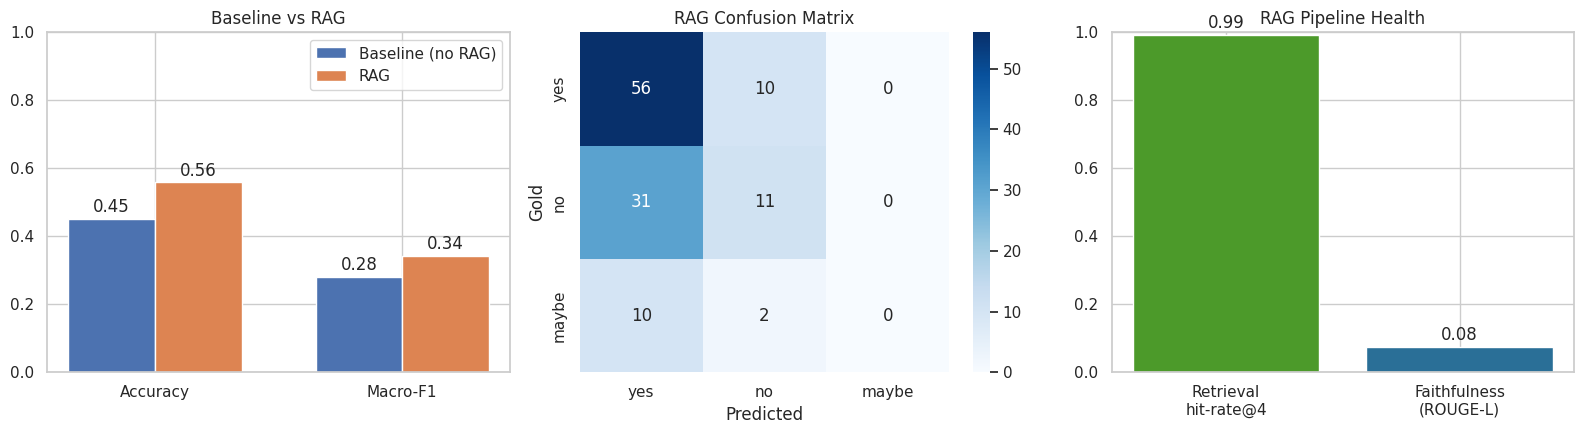

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Baseline vs RAG bar chart
metrics = ["accuracy", "macro_f1"]
x = np.arange(len(metrics)); w = 0.35
axes[0].bar(x - w/2, [base_score[m] for m in metrics], w, label="Baseline (no RAG)")
axes[0].bar(x + w/2, [rag_score[m]  for m in metrics], w, label="RAG")
axes[0].set_xticks(x); axes[0].set_xticklabels(["Accuracy", "Macro-F1"])
axes[0].set_ylim(0, 1); axes[0].set_title("Baseline vs RAG"); axes[0].legend()
for i, m in enumerate(metrics):
    axes[0].text(i - w/2, base_score[m] + .02, f"{base_score[m]:.2f}", ha="center")
    axes[0].text(i + w/2, rag_score[m]  + .02, f"{rag_score[m]:.2f}",  ha="center")

# (2) Confusion matrix for RAG
cm = confusion_matrix(rag_score["y_true"], rag_score["y_pred"], labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["yes","no","maybe"], yticklabels=["yes","no","maybe"], ax=axes[1])
axes[1].set_title("RAG Confusion Matrix"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Gold")

# (3) Pipeline health KPIs
kpis = {"Retrieval\nhit-rate@4": hit_rate, "Faithfulness\n(ROUGE-L)": faith["rougeL"]}
axes[2].bar(list(kpis.keys()), list(kpis.values()), color=["#4C9A2A", "#2A6F97"])
axes[2].set_ylim(0, 1); axes[2].set_title("RAG Pipeline Health")
for i, v in enumerate(kpis.values()):
    axes[2].text(i, v + .02, f"{v:.2f}", ha="center")

plt.tight_layout(); plt.show()

## 7. Interactive Demo Dashboard (Gradio)

A clickable demo: enter a biomedical question, see the retrieved evidence, the grounded answer, and
the retrieval scores. This is the artifact to screenshot / link in a portfolio — it makes the RAG
pipeline tangible to a non-technical reviewer.

Run the cell, then open the public `gradio.live` link.

In [21]:
import gradio as gr

def demo_fn(question, k):
    if not question.strip():
        return "Enter a question.", ""
    answer, hits = rag_answer(question, k=int(k))
    evidence = "\n\n".join(
        f"[score {h['score']:.3f} | doc {h['meta']['doc_id']}] {h['text']}" for h in hits
    )
    return answer, evidence

with gr.Blocks(title="Medical RAG QA") as demo:
    gr.Markdown("# Medical RAG Question Answering\nGrounded yes/no/maybe answers over PubMed abstracts.")
    with gr.Row():
        q_in = gr.Textbox(label="Biomedical question", lines=2,
                          placeholder="e.g. Does vitamin D supplementation reduce risk of respiratory infection?")
        k_in = gr.Slider(1, 8, value=4, step=1, label="Documents to retrieve (k)")
    btn = gr.Button("Ask", variant="primary")
    ans_out = gr.Textbox(label="Grounded answer")
    ev_out  = gr.Textbox(label="Retrieved evidence", lines=10)
    btn.click(demo_fn, inputs=[q_in, k_in], outputs=[ans_out, ev_out])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1bee7edebfa8ea649e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Findings, Limitations & Next Steps

**Findings**
- RAG conditions the generator on retrieved evidence, and the baseline-vs-RAG comparison isolates the
  contribution of retrieval (rather than the model) to answer quality.
- Retrieval hit-rate@4 confirms whether the correct source document is being surfaced — the
  prerequisite for any RAG gain.
- The faithfulness proxy quantifies grounding, giving a measurable hallucination signal instead of an
  unverified claim.

**Limitations**
- ROUGE-L is a lexical faithfulness proxy; a semantic LLM-as-judge or **RAGAS** (faithfulness,
  answer-relevance, context-precision) would be more robust.
- PubMedQA labels are yes/no/maybe; richer free-text QA (e.g. BioASQ) would stress generation more.
- `flan-t5-base` is intentionally small; swapping in a 4-bit 7B chat model is a one-line change.

**Next steps**
- Add **QLoRA fine-tuning** of the generator on PubMedQA and re-run this exact eval harness to show a
  fine-tuned-vs-RAG-vs-baseline three-way comparison.
- Replace `IndexFlatIP` with an **IVF/HNSW** FAISS index to demonstrate scalable retrieval.
- Integrate **RAGAS** for production-grade faithfulness scoring.

---
*This notebook demonstrates an end-to-end, evaluated RAG system: ingestion → FAISS retrieval →
grounded generation → statistical evaluation → visualization → interactive demo.*
